<a href="https://colab.research.google.com/github/anaPierrout/Fase1FIAP/blob/main/Fase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt

In [2]:
# ==========================================================
# LEITURA DA BASE
# ==========================================================

df = pd.read_csv("/content/desafio_nps_fase_1.csv")

print("Dimensões da base:")
print(df.shape)

df.head()

Dimensões da base:
(2500, 19)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
# ==========================================================
# DEFINIÇÃO DA VARIÁVEL TARGET
# ==========================================================

# Cliente é considerado detrator quando NPS <= 6
# 1 = detrator | 0 = não detrator

df["is_detrator"] = (
    df["nps_score"] <= 6
).astype(int)

# Distribuição da variável alvo
df["is_detrator"].value_counts()

,count
is_detrator,
1,1851
0,649


In [4]:
# ==========================================================
# REMOÇÃO DE DATA LEAKAGE
# ==========================================================

# Remoção de variáveis que não estariam disponíveis no momento da previsão

colunas_remover = [
    "customer_id",
    "order_id",
    "nps_score",
    "repeat_purchase_30d",
    "csat_internal_score"
]

df.drop(
    columns=[c for c in colunas_remover if c in df.columns],
    inplace=True
)

df.shape

(2500, 15)

In [5]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Criação de novas variáveis com base nos
# principais insights encontrados na EDA.

# Atraso crítico (3 dias ou mais)
df["atraso_critico"] = (
    df["delivery_delay_days"] >= 3
).astype(int)

# Muitos contatos com suporte
df["suporte_critico"] = (
    df["customer_service_contacts"] >= 3
).astype(int)

# Muitas reclamações
df["reclamacao_critica"] = (
    df["complaints_count"] >= 5
).astype(int)

# Tempo elevado de resolução
df["resolucao_lenta"] = (
    df["resolution_time_days"] >= 10
).astype(int)

# Score de risco operacional
df["risco_operacional_score"] = (
      df["atraso_critico"]
    + df["suporte_critico"]
    + df["reclamacao_critica"]
    + df["resolucao_lenta"]
)

df.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,is_detrator,atraso_critico,suporte_critico,reclamacao_critica,resolucao_lenta,risco_operacional_score
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,0,0,0,0,0
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,0,1,2
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1,0,2
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,0,0,0,1,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,0,0,0


In [6]:
# ==========================================================
# ENCODING DAS VARIÁVEIS CATEGÓRICAS
# ==========================================================

# Transforma variáveis categóricas em numéricas

for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [7]:
# ==========================================================
# DEFINIÇÃO DE X E y
# ==========================================================

X = df.drop(columns=["is_detrator"])
y = df["is_detrator"]

In [8]:
# ==========================================================
# DIVISÃO TREINO / TESTE
# ==========================================================

# 80% treino / 20% teste
# stratify mantém proporção da classe alvo

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# ==========================================================
# TREINAMENTO DOS MODELOS
# ==========================================================

# Random Forest (modelo principal)
modelo = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

modelo.fit(X_train, y_train)


# Regressão Linear (modelo baseline)
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

LinearRegression()

In [10]:
# ==========================================================
# GERAÇÃO DAS PREDIÇÕES
# ==========================================================

# Random Forest
predicoes = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)[:, 1]


# Regressão Linear
predicoes_lr_cont = modelo_lr.predict(X_test)

predicoes_lr = (
    predicoes_lr_cont >= 0.5
).astype(int)

In [11]:
# ==========================================================
# RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST
# ==========================================================

print(
    classification_report(
        y_test,
        predicoes
    )
)

              precision    recall  f1-score   support

           0       0.71      0.62      0.66       130
           1       0.87      0.91      0.89       370

    accuracy                           0.84       500
   macro avg       0.79      0.76      0.78       500
weighted avg       0.83      0.84      0.83       500



In [12]:
# ==========================================================
# MÉTRICAS - RANDOM FOREST
# ==========================================================

print("Recall:", recall_score(y_test, predicoes))
print("Precision:", precision_score(y_test, predicoes))
print("F1-Score:", f1_score(y_test, predicoes))
print("ROC-AUC:", roc_auc_score(y_test, probabilidades))

Recall: 0.9135135135135135
Precision: 0.8711340206185567
F1-Score: 0.8918205804749341
ROC-AUC: 0.8647193347193346


In [13]:
# ==========================================================
# RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LINEAR
# ==========================================================

print(
    classification_report(
        y_test,
        predicoes_lr
    )
)

              precision    recall  f1-score   support

           0       0.80      0.52      0.63       130
           1       0.85      0.95      0.90       370

    accuracy                           0.84       500
   macro avg       0.83      0.74      0.77       500
weighted avg       0.84      0.84      0.83       500



In [14]:
# ==========================================================
# MÉTRICAS - REGRESSÃO LINEAR
# ==========================================================

print("Recall:", recall_score(y_test, predicoes_lr))
print("Precision:", precision_score(y_test, predicoes_lr))
print("F1-Score:", f1_score(y_test, predicoes_lr))
print("ROC-AUC:", roc_auc_score(y_test, predicoes_lr_cont))

Recall: 0.9540540540540541
Precision: 0.8506024096385543
F1-Score: 0.8993630573248408
ROC-AUC: 0.8792307692307693


In [15]:
# ==========================================================
# MATRIZ DE CONFUSÃO
# ==========================================================

confusion_matrix(y_test, predicoes)

array([[ 80,  50],
       [ 32, 338]])

- Random Forest é o modelo “mais inteligente” aqui. Ele consegue enxergar padrões mais complexos nos dados (tipo combinações de problemas juntos). Por isso ele costuma ser mais confiável e equilibrado.
- Regressão Linear é um modelo mais “simples”. Ele olha cada variável de forma mais direta, sem entender bem combinações entre elas. Por isso ele serve mais como comparação básica, não como o melhor resultado.

In [16]:
# ==========================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================================

importancias = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    by="importancia",
    ascending=False
)

importancias.head(10)

,variavel,importancia
13,complaints_count,0.220101
8,delivery_delay_days,0.113764
18,risco_operacional_score,0.106978
14,atraso_critico,0.061749
3,order_value,0.056224
12,resolution_time_days,0.052062
9,freight_value,0.049933
16,reclamacao_critica,0.048728
5,discount_value,0.047098
2,customer_tenure_months,0.045728


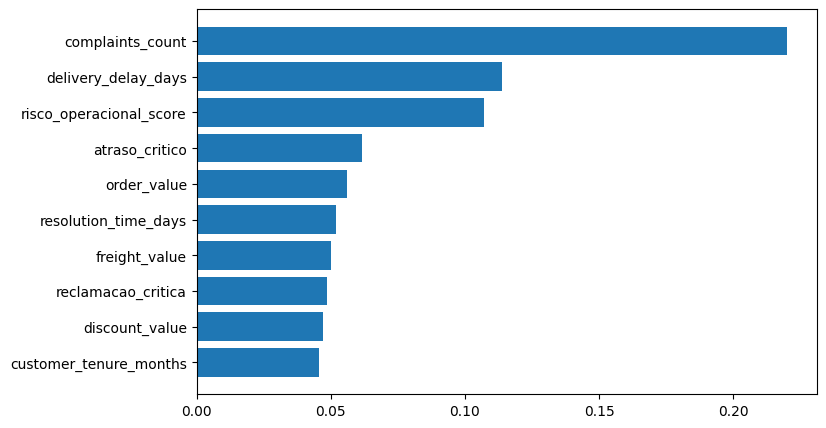

In [17]:
# ==========================================================
# VISUALIZAÇÃO DAS VARIÁVEIS MAIS IMPORTANTES
# ==========================================================

top10 = importancias.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["variavel"],
    top10["importancia"]
)

plt.gca().invert_yaxis()
plt.show()